## 1D Heat Conduction by Forward in Time, Centered in Space (FTCS) Method

### Governing equation
\begin{equation}
\frac{\partial T}{\partial t} = \alpha \frac{\partial^2 T}{\partial ^2 x}
\end{equation}

Dirichlet boundary conditions:
\begin{equation}
T(x=0,t)=0\,^\circ \mathrm{C}
\end{equation}
\begin{equation}
T(x=L,t)=100\,^\circ \mathrm{C}
\end{equation}

Initial condition $T(x,0) = 0 \,^\circ \mathrm{C}$


A fin of length $L$ is initially at $T(x,0) = 0 \,^\circ \mathrm{C}$ along the entire length of the fin. Then suddenly a temperature of $T(x=L,t)=100\,^\circ \mathrm{C}$ is applied to the right end and the left end is held fixed at T(x=0,t)=0\,^\circ \mathrm{C}$.

We seek to compute the temperature profile along the bar as a function of time. Assume the fin properties are typical for copper.

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [44]:
# Define material paramters
k = 400
cp = 385
rho = 8960
alpha = k/(rho*cp)

In [69]:
# Define geometry
L = 1.0 #Length of bar
N = 6 # number of grid points
x = np.linspace(0,L,N) # array containing grid point locations for plotting later
dx = L/(N-1) # grid spacing
dt = 100.0 # time step
lam = alpha*dt/dx**2
lam # make sure lam < 1/2

0.2898886827458256

In [70]:
# Define end temperatures
T_0 = 0.0
T_N = 100.0

In [71]:
# Time loop
nsteps = 50
T = np.zeros((nsteps+1,len(x)))
#
for n in range(nsteps):
    # Loop over grid points
    for i in range(1,N-1):
        T[n+1,i]=T[n,i] + lam*(T[n,i+1]-2.*T[n,i]+T[n,i-1])
    # Enforce Dirichlet Boundary conditions
    T[n+1,0] = T_0
    T[n+1,N-1] = T_N

In [72]:
df = pd.DataFrame(T) # converts Temperature array to dataframe for post processing
df.to_csv('temperature_vs_x_t.csv') #saves Temperature versus time data to .csv file in your local directory

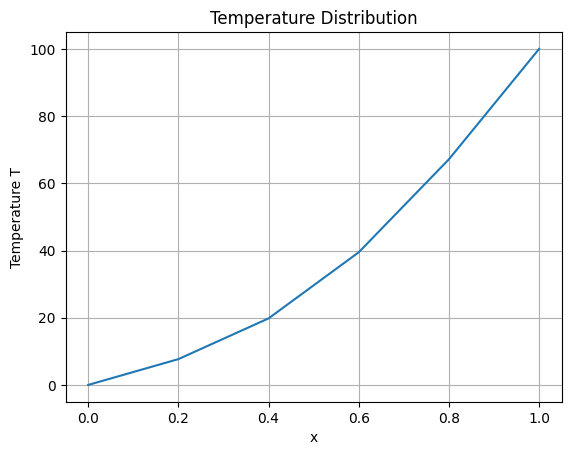

In [73]:
plt.plot(x, T[10,:]) # plot x versus T along bar at time n=10
plt.xlabel("x")
plt.ylabel("Temperature T")
plt.title("Temperature Distribution")
plt.grid(True)
plt.show()

In [74]:
df

,0,1,2,3,4,5
0,0.0,0.000000,0.000000,0.000000,0.000000,0.0
1,0.0,0.000000,0.000000,0.000000,0.000000,100.0
2,0.0,0.000000,0.000000,0.000000,28.988868,100.0
3,0.0,0.000000,0.000000,8.403545,41.170647,100.0
4,0.0,0.000000,2.436093,15.466264,48.725799,100.0
5,0.0,0.706196,5.507196,21.330528,53.948047,100.0
6,0.0,1.893233,8.702445,26.198973,57.842537,100.0
7,0.0,3.318320,11.800577,30.300039,60.890397,100.0
8,0.0,4.815287,14.704451,33.805053,63.360030,100.0
9,0.0,6.286146,17.374743,36.835658,65.413889,100.0
